In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import PIL.Image
import urllib.request
import numpy as np
import plotly.io as pio

In [2]:
# Carregando os dados já limpos e tratados
base_tratada = pd.read_parquet('base_tratada.parquet')

# Verificando se as colunas de amenidades continuam como booleanas
print(base_tratada[['internet_wifi', 'ar condicionado', 'tv', 'água quente', 'piscina']].dtypes)
print(f"Total de registros carregados: {len(base_tratada)}")

internet_wifi      bool
ar condicionado    bool
tv                 bool
água quente        bool
piscina            bool
dtype: object
Total de registros carregados: 622366


In [3]:
base_tratada.dtypes

host_is_superhost                     str
host_listings_count               float64
latitude                          float64
longitude                         float64
property_type                         str
room_type                             str
accommodates                        int64
bathrooms                         float64
bedrooms                          float64
beds                              float64
bed_type                              str
price                             float32
extra_people                      float32
minimum_nights                      int64
maximum_nights                      int64
instant_bookable                      str
cancellation_policy                   str
calculated_host_listings_count      int64
ano                                 int64
mes                                 int64
internet_wifi                        bool
ar condicionado                      bool
tv                                   bool
água quente                       

### Média de Preço por Propriedade

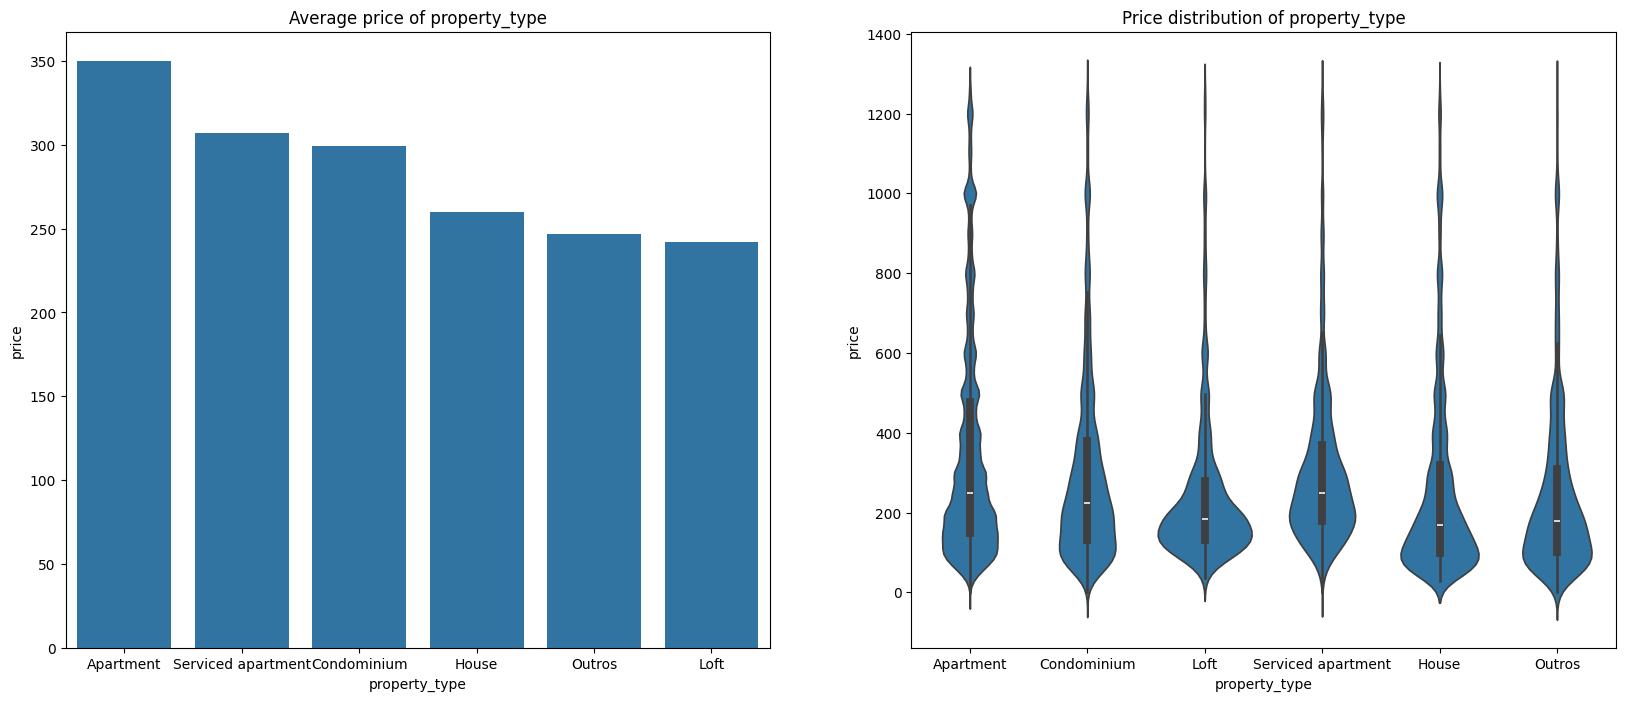

In [4]:
aa = base_tratada.groupby(by='property_type').mean(numeric_only=True).sort_values(by='price',ascending=False).iloc[0:6]
fig, (ax1,ax2) = plt.subplots(1,2)
fig.set_size_inches(20,8)
violin_data=base_tratada.loc[base_tratada['property_type'].isin(aa.index)]
_ =  sns.barplot(x=aa.index, y='price', data=aa,ax=ax1)
_ = ax1.set_title('Average price of property_type')
_ = ax2.set_title('Price distribution of property_type')
_ = sns.violinplot(x = 'property_type', y =  'price',data=violin_data,ax=ax2)

## Visualização do Mapa das Propriedades

In [5]:
#COORDINATES TO PLOT THE MAP
box = (base_tratada.longitude.min(), base_tratada.longitude.max(), base_tratada.latitude.min(), base_tratada.latitude.max())
box1 = (-43.7370,-43.1041,-23.0729,-22.7497)

In [6]:
# 1. Abre a URL e carrega a imagem usando Pillow e Numpy
url = 'https://i.ibb.co/52dDkxT/map-8.png'
with urllib.request.urlopen(url) as response:
    a = np.array(PIL.Image.open(response))

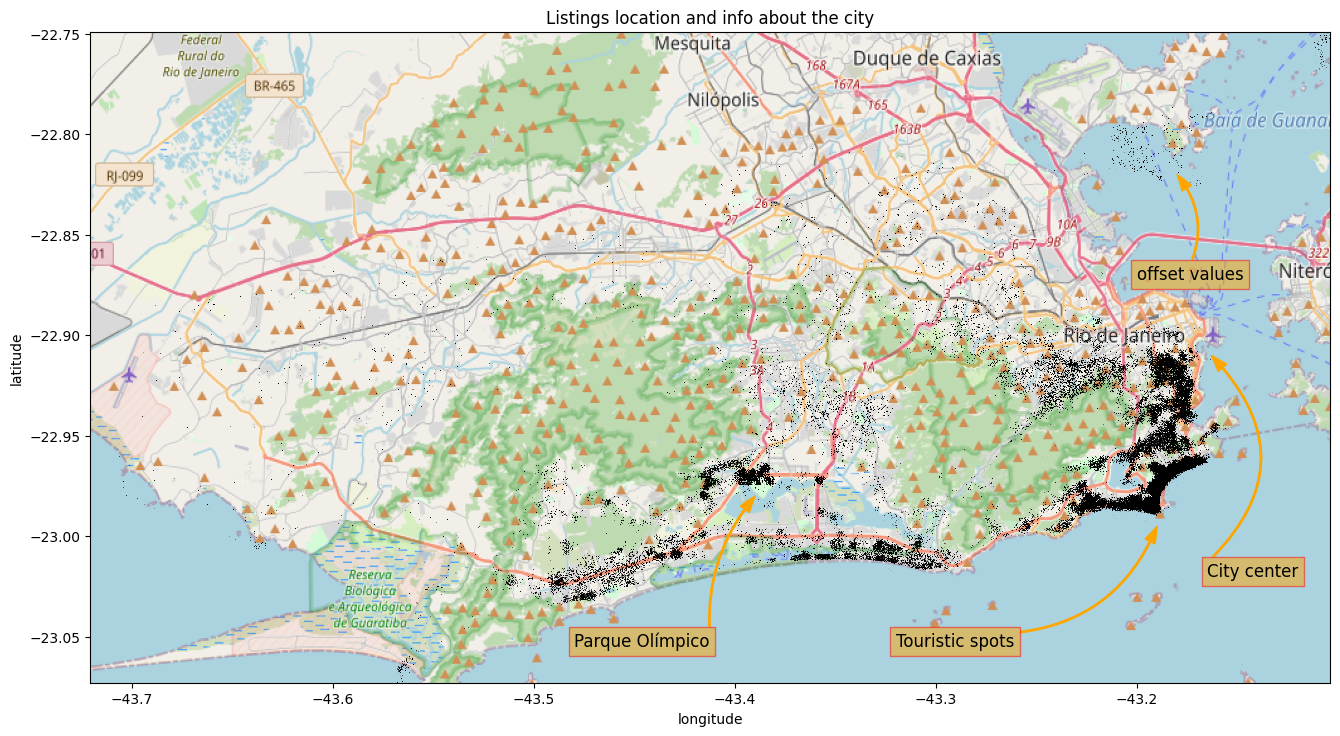

In [7]:
fig, ax= plt.subplots()
fig.set_size_inches(16,12)

ax.imshow(a,zorder=0, extent=(box[0],-43.1041,-23.082,box[3]), aspect='equal')
ax.set_title('Listings location and info about the city')
ax.set_xlim(box[0],box[1])
ax.set_ylim(box[2],box[3])#-23.0729
ax.annotate('offset values',
            xy=(-43.18, -22.82),
            xytext=(-43.2,-22.872), backgroundcolor='yellow',bbox=dict(facecolor='#ffa500', alpha=0.5, edgecolor='red', joinstyle='round'),
            arrowprops=dict(headwidth=8, width=1, color='#ffa500', connectionstyle="arc3, rad=0.3"),
            fontsize=12)
ax.annotate('Parque Olímpico',
            xy=(-43.39, -22.98),
            xytext=(-43.48,-23.055), backgroundcolor='yellow',bbox=dict(facecolor='#ffa500', alpha=0.5, edgecolor='red', joinstyle='round'),
            arrowprops=dict(headwidth=8, width=1, color='#ffa500', connectionstyle="arc3, rad=-0.2"),
            fontsize=12)
ax.annotate('City center',
            xy=(-43.163, -22.91),
            xytext=(-43.165,-23.02), backgroundcolor='yellow',bbox=dict(facecolor='#ffa500', alpha=0.5, edgecolor='red', joinstyle='round'),
            arrowprops=dict(headwidth=8, width=1, color='#ffa500', connectionstyle="arc3, rad=0.5"),
            fontsize=12)
ax.annotate('Touristic spots',
            xy=(-43.19, -22.995),
            xytext=(-43.32,-23.055), backgroundcolor='yellow',bbox=dict(facecolor='#ffa500', alpha=0.5, edgecolor='red', joinstyle='round'),
            arrowprops=dict(headwidth=8, width=1, color='#ffa500', connectionstyle="arc3, rad=0.3"),
            fontsize=12)
_ = sns.scatterplot(x='longitude', y='latitude', data=base_tratada, ax=ax, zorder=1,color='black',alpha=0.6, s=0.1,edgecolor=None)

In [8]:
# Força o plotly a renderizar no formato correto para o seu editor
pio.renderers.default = "notebook_connected"

base_tratada_density_mapbox = base_tratada.sample(n=50000)
map_center = {'lat':base_tratada_density_mapbox.latitude.mean(), 'lon':base_tratada_density_mapbox.longitude.mean()}
mapa = px.density_mapbox(base_tratada_density_mapbox, 
                        lat='latitude', 
                        lon='longitude',
                        z='price',
                        title=10*' '+'Daily Price density', 
                        radius=2.5,
                        center=map_center, 
                        zoom=10,
                        mapbox_style='open-street-map') # Estilo que sempre funciona
mapa.show()


C:\Users\Andre\AppData\Local\Temp\ipykernel_8152\2796256695.py:6: DeprecationWarning: *density_mapbox* is deprecated! Use *density_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  mapa = px.density_mapbox(base_tratada_density_mapbox,


## Encoding

###### Preicsamos ajustar as features para o modelo de aprendizagem

In [9]:

# Verdadeiro ou Falso
## lista de colunas
colunas_bool = ['host_is_superhost', 'instant_bookable', 'internet_wifi', 
                'ar condicionado', 'tv', 'água quente', 'piscina']


base_tratada_cod = base_tratada.copy()

for coluna in colunas_bool:
    # 1. Substitui t/f por 1/0 (funciona mesmo se a coluna for mista)
    base_tratada_cod[coluna] = base_tratada_cod[coluna].replace({'t': 1, 'f': 0})
    
    # 2. Preenche eventuais valores vazios com 0 antes de converter para int
    # (Opcional: use apenas se houver valores nulos na sua base)
    base_tratada_cod[coluna] = base_tratada_cod[coluna].fillna(0).astype(int)

# 3. Exibe a primeira linha das colunas booleanas agora como 0 e 1
print(base_tratada_cod[colunas_bool].iloc[0])

host_is_superhost    0
instant_bookable     0
internet_wifi        1
ar condicionado      1
tv                   1
água quente          0
piscina              0
Name: 0, dtype: int64


In [10]:
#String
##liste de colunas

In [11]:
colunas_str = ['property_type', 'room_type', 'bed_type', 'cancellation_policy']

# Criar dummies apenas para as colunas especificadas
# drop_first=True evita a redundância (armadilha da variável dummy)
base_tratada_cod = pd.get_dummies(base_tratada_cod, columns=colunas_str, drop_first=True)

# Converter as novas colunas dummies de bool para int (0 e 1)
# O pandas moderno gera True/False por padrão no get_dummies
colunas_novas = base_tratada_cod.select_dtypes(include=['bool']).columns
base_tratada_cod[colunas_novas] = base_tratada_cod[colunas_novas].astype(int)

display(base_tratada_cod.head())


,host_is_superhost,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,extra_people,...,property_type_Loft,property_type_Outros,property_type_Serviced apartment,room_type_Hotel room,room_type_Private room,room_type_Shared room,bed_type_Real Bed,cancellation_policy_flexible,cancellation_policy_moderate,cancellation_policy_strict_14_with_grace_period
0,0,1.0,-22.946854,-43.182737,4,1.0,0.0,2.0,133.0,34.0,...,0,0,0,0,0,0,1,0,0,1
1,1,2.0,-22.965919,-43.178962,5,1.0,2.0,2.0,270.0,51.0,...,0,0,0,0,0,0,1,0,0,0
2,0,3.0,-22.977117,-43.190454,3,1.0,1.0,2.0,161.0,45.0,...,0,0,0,0,0,0,1,0,0,0
3,1,1.0,-22.983024,-43.214270,3,1.0,1.0,2.0,222.0,68.0,...,0,0,0,0,0,0,1,0,0,0
4,1,1.0,-22.988165,-43.193588,3,1.5,1.0,2.0,308.0,86.0,...,0,0,0,0,0,0,1,0,0,0


colunas_ctg = ('property_type', 'room_type', 'bed_type', 'cancellation_policy'),

In [12]:
print(base_tratada_cod.dtypes)

host_is_superhost                                    int64
host_listings_count                                float64
latitude                                           float64
longitude                                          float64
accommodates                                         int64
bathrooms                                          float64
bedrooms                                           float64
beds                                               float64
price                                              float32
extra_people                                       float32
minimum_nights                                       int64
maximum_nights                                       int64
instant_bookable                                     int64
calculated_host_listings_count                       int64
ano                                                  int64
mes                                                  int64
internet_wifi                                        int

### Salvando o DataFrame tratado em formato Parquet

In [13]:

base_tratada_cod.to_parquet('base_cod.parquet', index=False)

print("Arquivo 'base_tratada_cod.parquet' salvo com sucesso!")

Arquivo 'base_tratada_cod.parquet' salvo com sucesso!
